In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns



In [2]:
df=pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## exploratory data analysis

In [3]:
df.shape

(32581, 12)

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [5]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
df['loan_status'].unique()
#classification problem ...it mostly leads to class imbalance..jo value sabse xyada aati uspe model zyada foxus karta

array([1, 0])

In [7]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

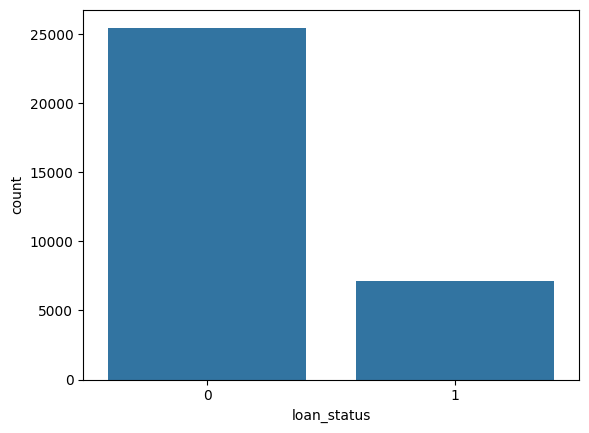

In [8]:
sns.countplot(x='loan_status',data=df)
#we can see simply thta there is a class imbalance 

In [9]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


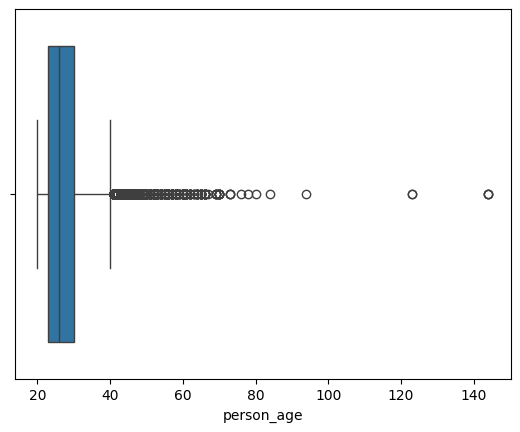

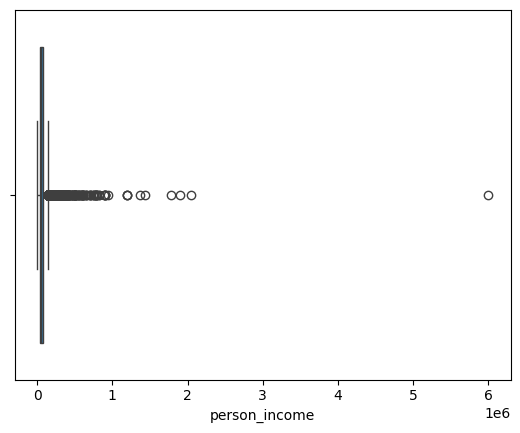

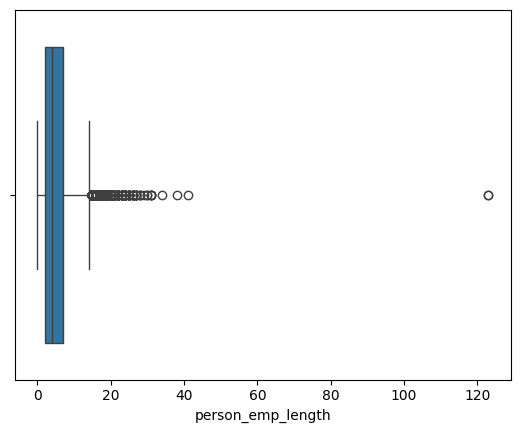

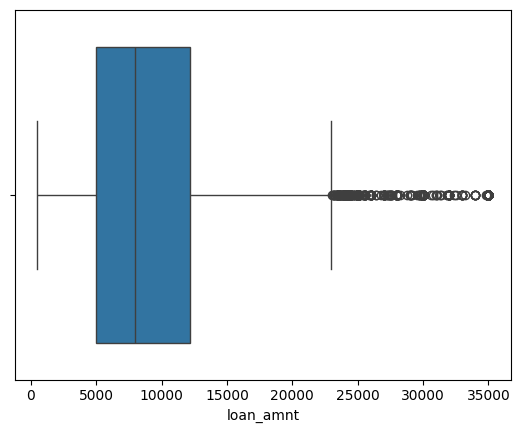

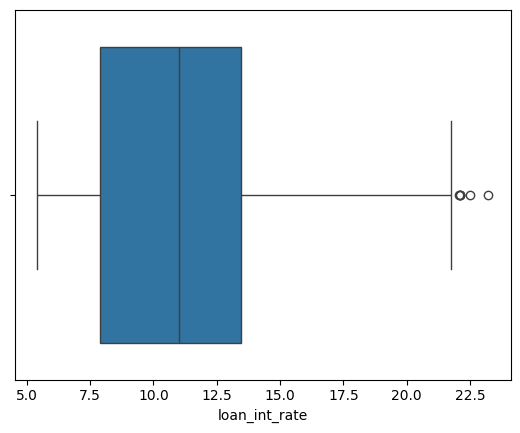

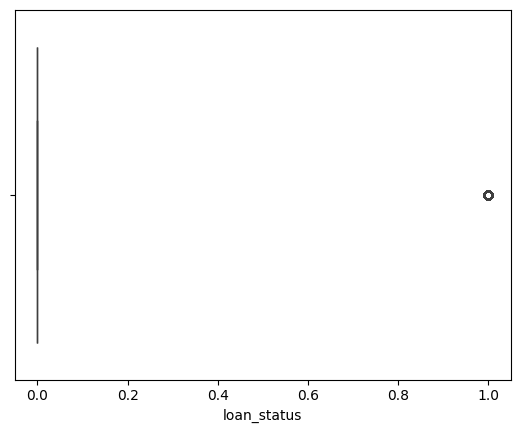

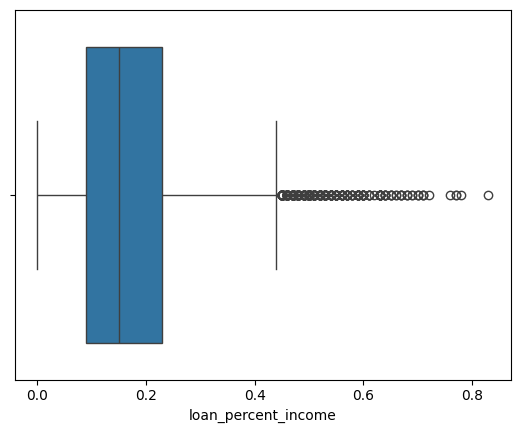

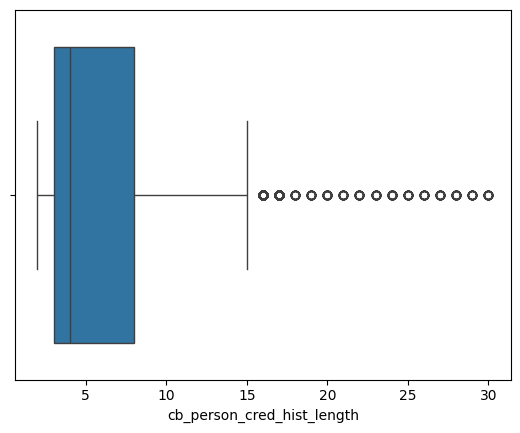

In [10]:
numerical_cols=df.select_dtypes(include=np.number).columns
for i in numerical_cols:
    sns.boxplot(x=df[i])
    plt.show()

In [11]:
(df['person_age']>100).sum() #we have 5 people whose age is greater than 100

np.int64(5)

In [12]:
(df['person_emp_length']>60).sum()

np.int64(2)

<Axes: >

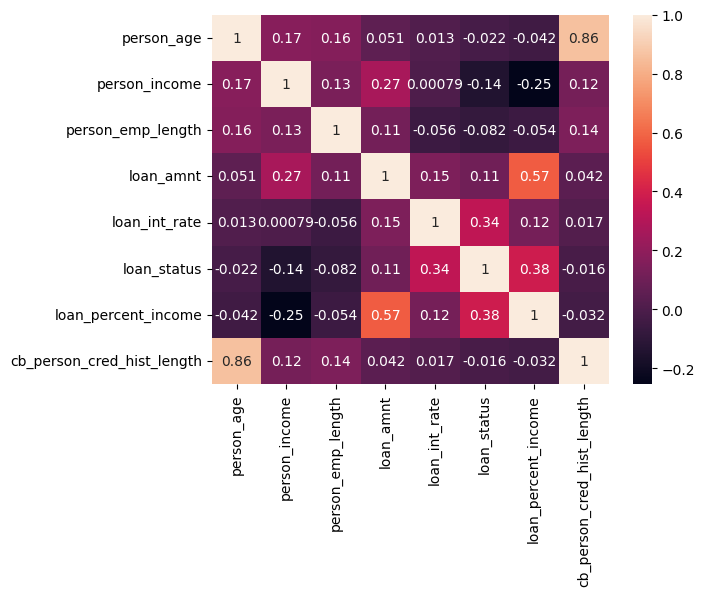

In [13]:
#correlation check 
sns.heatmap(df.corr(numeric_only=True),annot=True)

## Data Validation and outlier handling 

In [14]:
df_copy=df.copy()

In [15]:
#remove duplicate rows
print(f"original count of the rows: {df_copy.shape[0]}")
df_copy.drop_duplicates(inplace=True)
print(f"Row count after removing the duplicates {df_copy.shape[0]}")

original count of the rows: 32581
Row count after removing the duplicates 32416


In [16]:
# remove the ages below 18 and above 100 and remove employment greater than age or extreme outlier
df_copy=df_copy[(df_copy['person_age'] >= 18) & (df_copy['person_age'] <= 100)]
df_copy

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [17]:
df_copy=df_copy[(df_copy['person_emp_length']<=df_copy['person_age']) & (df_copy['person_emp_length']<=60)]
df_copy

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [19]:
#remove the rows with 0 or negative income and loan amount 
df_copy=df_copy[df_copy['loan_amnt']>0]

In [20]:
X=df_copy.drop('loan_status',axis=1)
y=df_copy['loan_status']

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
#stratify=y means equal amount of 0 and 1 should be  into training and testing 

In [22]:
numerical_cols=['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']

categorical_cols=['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']

## Handle class imablance

In [25]:
#class weights enables the model to pay attention on the class which is less so basicall ye bas minority class pe weights assign karta and fir hamara model us pe utna he equally dhyan dega 
#logiostic regression me class wright inbuilt hota hai 
#xgboost  dont have class weight 


#0-no laon 
#1- loan 
neg,pos=np.bincount(y_train) #0 hai 19772 and 1 hai 5445 same as value_counts
scale_weights=neg/pos #this is how we calculated the class wight for xgboost because it dont have inbuilt method 
scale_weights


np.float64(3.6312213039485766)

## Logistic Regression

In [26]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [27]:
#columntransformer columns ko respective pipeline me transform karta 
preprocessor_lr=ColumnTransformer(
    transformers=[
        #pipeline for numerical columns
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',StandardScaler())
        ]),numerical_cols),
         #pipeline for categorical columns
        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy='constant',fill_value="Missing")),
            ('encode',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ]
)